In [2]:
from files.functions import *
import numpy as np
import pandas as pd
import warnings
from files.xgboostImplementation import XGBoost
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')

In [6]:
data = pd.read_csv(f'../data/{COIN}_df.csv')
data = data.loc[:, ~data.columns.str.contains('^Unnamed:')]
merged = dataSetup(data, trainingColPath='../files/training_columns.txt')
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,low,high,open,close,gradient
time,,,,,,,,,,,,,
2015-07-20,268.225208,299.188792,71.0,0.000000,782.883420,-3.817129e+06,283.615714,4417.348637,277.37,280.00,277.98,280.00,0.00
2015-07-21,266.070954,300.106046,71.0,0.000000,4943.559434,-3.817912e+06,285.645714,5228.512882,276.85,281.27,279.96,277.32,-2.68
2015-07-22,263.804410,301.155590,71.0,0.000000,4687.909383,-3.812968e+06,288.280000,5345.414337,275.01,278.54,277.33,277.89,0.57
2015-07-23,263.024045,301.345955,71.0,0.000000,5306.919575,-3.817656e+06,290.037143,5421.928306,276.28,279.75,277.96,277.39,-0.50
2015-07-24,261.412051,301.912949,71.0,0.000000,7362.469083,-3.812349e+06,291.622857,5397.937160,276.43,291.52,277.23,289.12,11.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-15,103144.495964,123587.093036,70.0,0.000627,23726.313561,-3.335235e+04,118689.097143,0.000000,115697.37,119973.30,119863.71,117781.64,-2082.07
2025-07-16,103144.495964,123587.093036,68.0,-5.189416,9250.986426,-9.626039e+03,118689.097143,0.000000,117033.23,120134.80,117781.63,118681.68,900.04
2025-07-17,103144.495964,123587.093036,70.0,9.995038,8360.351309,-3.750526e+02,118689.097143,0.000000,117469.00,120998.76,118681.67,119273.69,592.01


# XGBoost Implementation

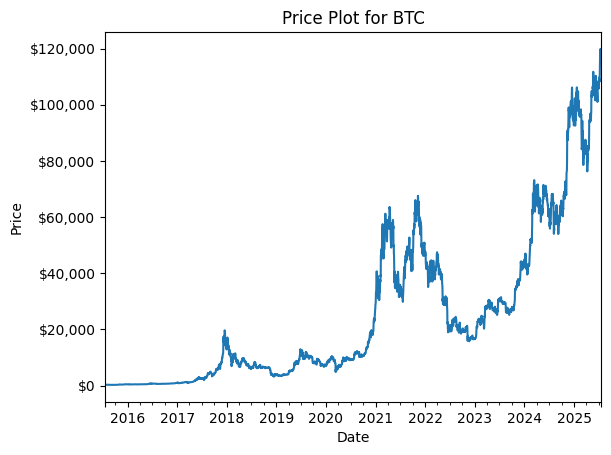

In [7]:
merged['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
# format y axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

In [8]:
scaler = StandardScaler()
closeScaler = StandardScaler()
mergedIndex = merged.index
mergedCols = merged.columns

mergedWithoutClose = merged.drop(columns=['close'])
mwocCols = mergedWithoutClose.columns
mwocIndex = mergedWithoutClose.index
mergedWithoutClose = scaler.fit_transform(mergedWithoutClose)
mergedWithoutClose = pd.DataFrame(mergedWithoutClose, index=mergedIndex, columns=mwocCols)

merged['close'] = closeScaler.fit_transform(merged['close'].values.reshape(-1, 1))
merged = pd.concat([mergedWithoutClose, merged['close']], axis=1)
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,low,high,open,gradient,close
time,,,,,,,,,,,,,
2015-07-20,-0.882445,-0.921143,0.267001,-0.013960,-1.146472,-1.991674,-0.903383,-1.124557,-0.899304,-0.906262,-0.903339,-0.029557,-0.903160
2015-07-21,-0.882528,-0.921113,0.267001,-0.013960,-0.789617,-1.992348,-0.903310,-1.030743,-0.899323,-0.906217,-0.903268,-0.032013,-0.903256
2015-07-22,-0.882616,-0.921079,0.267001,-0.013960,-0.811544,-1.988093,-0.903216,-1.017222,-0.899391,-0.906313,-0.903362,-0.029034,-0.903235
2015-07-23,-0.882646,-0.921073,0.267001,-0.013960,-0.758452,-1.992128,-0.903153,-1.008373,-0.899344,-0.906270,-0.903339,-0.030015,-0.903253
2015-07-24,-0.882708,-0.921054,0.267001,-0.013960,-0.582150,-1.987560,-0.903097,-1.011148,-0.899338,-0.905856,-0.903366,-0.018804,-0.902833
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-15,3.090989,3.119352,0.148113,-0.011975,0.821354,1.265488,3.326634,-1.635444,3.329854,3.307798,3.390163,-1.938060,3.309616
2025-07-16,3.090989,3.119352,-0.089662,-16.445410,-0.420175,1.285912,3.326634,-1.635444,3.378802,3.313484,3.315410,0.795454,3.341885
2025-07-17,3.090989,3.119352,0.148113,31.633717,-0.496563,1.293876,3.326634,-1.635444,3.394769,3.343902,3.347724,0.513102,3.363111


In [12]:
training_cols = trainingCols('../files/training_columns.txt')
X = merged[training_cols]
y = merged['close']
n = len(data)

merged = transformerDataSetup(merged)
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(merged, testSize=len(merged)-TEST_DAYS)
train_stuff = merged.loc[X_train.index, training_cols]
test_stuff = merged.loc[X_test.index, training_cols]
X_train_norm = pd.concat([X_train, train_stuff], axis=1)
X_test_norm = pd.concat([X_test, test_stuff], axis=1)

X_train_norm.shape, X_test_norm.shape, y_train.shape, y_test.shape

((3646, 12), (7, 12), (3646,), (7,))

In [16]:
xgb_model = XGBoost(
    base_estimator=RandomForestRegressor(n_estimators=50),
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
)

In [17]:
xgb_model.fit(X_train_norm, y_train)
with open(f'../models/{COIN}_full_xgb_model_everything.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x106a996a0>>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

In [15]:
predictions = xgb_model.predict(X_test_norm.iloc[[-1]]) # Predicting for the future 7 days
modelName = 'full_xgb_model_everything'
predictions = np.array(predictions)
predictions = predictions.reshape(-1, 1)
predictions = closeScaler.inverse_transform(predictions)
predictions = pd.DataFrame(predictions, columns=['predictions'])
predictions.index = pd.date_range(start=merged.index.max(), periods=TEST_DAYS, freq='D')
if not os.path.exists(f'predictions/{COIN}'):
    os.makedirs(f'predictions/{COIN}')
predictions.to_csv(f'predictions/{COIN}/{modelName}_predictions.csv')
predictions.plot.line()
plt.title(f'XGBoost Predictions for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
plt.show()

IndexError: list index out of range

In [ ]:
predictions_1 = xgb_model.predict(X_test_norm.iloc[[-2]])
predictions_1 = np.array(predictions_1)
predictions_1 = predictions_1.reshape(-1, 1)
predictions_1 = closeScaler.inverse_transform(predictions_1)
predictions_1 = pd.DataFrame(predictions_1, columns=['predictions'])
predictions_1['actual'] = closeScaler.inverse_transform(np.array(y_test.iloc[-2]).reshape(-1, 1))

predictions_1.index = pd.date_range(merged.index.max()-pd.Timedelta(days=1), periods=len(predictions_1), freq='D')
predictions_1.plot.line()
mse = mean_squared_error(predictions_1['actual'], predictions_1['predictions'], squared=False)
plt.title(f'Predictions vs Actual for {COIN} - Last 2 Days\nRMSE = ${mse:.2f}')
plt.show()